# Optical nerve preprocessing

## Setup

### Import libraries:

In [1]:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())
#import pandas as pd
import numpy as np
#import scipy as sc
from scipy.ndimage import distance_transform_edt
#import seaborn as sns
import matplotlib.pyplot as plt
#import matplotlib.image as mpimg
%matplotlib inline
from skimage import io
from skimage import measure
#from skimage import color
from PIL import Image
from pathlib import Path
from math import *
from read_roi import read_roi_zip
#from shapely.geometry import Point, Polygon, MultiPolygon, GeometryCollection
from shapely.geometry import Polygon
from shapely.validation import explain_validity, make_valid

from utils import *

/home/jovyan
/home/jovyan/projects/cellcount


### Define environment variables:

In [2]:
# microns/pixel ratio from in the optic nerve (ON) image:
# the ratio is about the same for all species: microns/pixel ratio =~ 0.1 
# except for Aa14 where it is =~0.07
PX_RATIOS = {
    'Aa06': 1216.66/12285,
    'Aa14': 1228.76/18684, # different resolution
    'Cj22': 1671.23/16875,
    'Cl': 1588.34/16038,
    'Du26': 847.35/8556,
    'Du25': 1026.80/10368,
    'Fp23': 2510.86/25353,
    'Ft10': 1949.32/19683,
    'Hr11': 1032.15/10422,
    'Hr21': 1120.39/11313,
    'Mc12': 1112.37/11232,
}
# for s, r in PX_RATIOS.items():
#     print(s, r)

ON_FOLDER_NAME = {
    'Aa06': "ON1_1/Aa06 - ON1_1 6_3",
    'Aa14': "ON1_1",
    'Cj22': "ON1_1",
    'Cl': "Cl_PV_ON",
    'Du26': "ON1_1",
    'Du25': "Du25_ON2",
    'Fp23': "ON2",
    'Ft10': "ON1_1",
    'Hr11': "ON1_1",
    'Hr21': "ON1_1",
    'Mc12': "ON1_1",   
}

ON_IMAGE_FILENAMES = {
    'Aa06': "Aa06 - ON1_1 6_3 - 2 - 63x-Stitching-02.czi - Aa06 - ON1_1 6_3 - 2 - 63x-Stitching-02.czi #1.tif",
    'Aa14': "Aa14_ON2_4_4-1-63x-Stitching-05.czi - Aa14_ON2_4_4-1-63x-Stitching-05.czi #1.tif",
    'Cj22': "Cj22_ON1_5-1_1-63x-Stitching-05.czi - Cj22_ON1_5-1_1-63x-Stitching-05.czi #1.tif",
    'Cl': "ClCl PV 10W ON 3_3 - 1 - 63x overview-Stitching-01.czi #1.tif",
    'Du26': "Du26_ON1_6bis_1-63x_2-Stitching-02.czi - Du26_ON1_6bis_1-63x_2-Stitching-02.czi #1.tif",
    'Du25': "Du25_ON2_6-Stitching-02.czi - Du25_ON2_6-Stitching-02.czi #1_crop.tif",
    'Fp23': "Fp23_ON2_7-3-63x-Stitching-01.czi - Fp23_ON2_7-3-63x-Stitching-01.czi #1.tif",
    'Ft10': "Ft10_ON1_9-Stitching-01.czi - Ft10_ON1_9-Stitching-01.czi #1_crop.tif",
    'Hr11': "Hr11 - ON1_1 6_4 - 2 - 63x overview-Stitching-04.tif",
    'Hr21': "Hr21_ON2_5-4_1-63x-Stitching-03.czi - Hr21_ON2_5-4_1-63x-Stitching-03.czi #1.tif",
    'Mc12': "Mc12_ON2_7bis_2-63x-Stitching-03.czi - Mc12_ON2_7bis_2-63x-Stitching-03.czi #1.tif"
}


### Choose parameters:

In [3]:
## Set species here:
species = 'Hr11'

save_intermediary_data = False
save_final_data = False

### Define paths:

In [ ]:
# mainpath:
path2kdrive = "/home/jovyan/kDrive"
# paths to store data ready for training/validation/testing the CNN network:
path2train = os.path.join(path2kdrive, "cellcount/data/onunet/optical_nerve/train")
path2validation = os.path.join(path2kdrive, "cellcount/data/onunet/optical_nerve/validation")
path2test = os.path.join(path2kdrive, "cellcount/data/onunet/optical_nerve/test")
# paths to original ON images:
path2rawimages = os.path.join(path2kdrive, "cellcount/data/BVSA-Histology-Epoxy")
foldername = ON_FOLDER_NAME[species]
imagefilename = ON_IMAGE_FILENAMES[species]
# paths to store preprocessed data (tiles partitionning the whole ON image) for a given species:
path2data = os.path.join(path2kdrive, "cellcount/data/preprocessing", species, "ON1_1")
print(f"Preprocessed data for species {species} will be stored at the following location: {path2data}")
path2tiles = os.path.join(path2data, 'tiles_512x512')
path2selection = os.path.join(path2data, "selection")

Preprocessed data for species Hr11 will be stored at the following location: /home/jovyan/kDrive/cellcount/data/preprocessing/Hr11/ON1_1


## Load and display original ON image

In [ ]:
## open file with whole optical nerve image:
im = io.imread(os.path.join(path2rawimages, species, foldername, imagefilename))
px_ratio = PX_RATIOS[species]
# # convert image to array and check its properties:
print(f"Data type {im.dtype}")
print(f"Image dimensions: {im.shape}")
print(f"Extreme pixel values are: min={np.min(im)} ; max={np.max(im)}")
#imarray = np.array(im)

Data type uint8
Image dimensions: (12231, 10422)
Extreme pixel values are: min=0 ; max=255


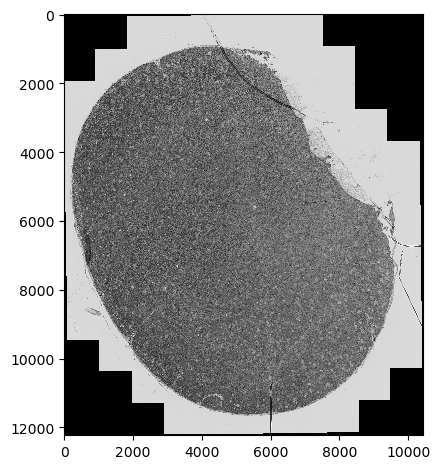

In [6]:
io.imshow(im)

## Partition original optic nerve image into tiles

### Define parameters to keep/discard tiles that are not covering the ON:

In [7]:
## parameters passed to should_discard_tile for first automatic check of whether keep/discard a tile:
TILE_FILTERING_PARAMS = {
    "Hr11": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.7},
    "Aa06": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.7},
    "Mc12": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.75},
    "Cl": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.75},
    "Aa14": { "density_thr_high": 0.035, "density_thr_low": 0.002, "nb_thr_high": 1, "ratio_thr_low": 0.5},
    "Hr21": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.75},
    "Cj22": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.75},
    "Du26": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.75},
    "Fp23": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.75},
    "Ft10": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.75},
    "Du25": { "density_thr_high": 0.035, "density_thr_low": 0.005, "nb_thr_high": 1, "ratio_thr_low": 0.75},
}

## manually overrule which tile should be kept or discarded:
KEEP_TILES = {
    # "Hr11": [],
    # "Aa06": [],
    "Mc12": [(9,3), (14,20), (15,20), (25,12), (26,11)],
    # "Cl": [],
    # "Aa14": [],
    "Hr21": [(1,6), (2,20), (2,4), (4,2), (6,1), (8,0), (9,0), (10,0), (14,2), (13,15), (15,4), (15,9), (14,12), (11,18), (8,20), (1,19), (0,18)],
    # "Cj22": [],
    "Du26": [(0,3), (0,7), (1,1), (2,11), (5,14), (9,2), (10,15), (12,14), (13,13), (14,8), (14,10), (14,11)],
    # "Fp23": [],
    "Ft10": [(1,27), (4,31), (5,32), (11,35), (12,35), (16,35), (22,34), (25,33), (28,31), (30,29), (32,27)],
    "Du25": [(2,7), (1,9), (1,15), (2,17), (6,19), (7,19), (8,19), (13,16), (14,14), (16,3), (15,2), (14,1), (11,0), (10,0), (9,0), (5,2), (3,5)]
}

DISCARD_TILES = {
    "Ft10": [(13,5), (11,6), (10,7), (9,8), (8,9), (7,10), (6,11), (5,12), (10,35)]
}

for k in TILE_FILTERING_PARAMS:
    TILE_FILTERING_PARAMS[k]['keep_list'] = KEEP_TILES.get(k, [])
    TILE_FILTERING_PARAMS[k]['discard_list'] = DISCARD_TILES.get(k, [])

### Partition and optionaly save tiles:

In [8]:
## Set tiles dimensions:
tile_height = 512
tile_width = 512

tiles_suffix = "tiles_" + str(tile_height) + "x" + str(tile_width)
tiles = partition_image(im,
    tile_height,
    tile_width,
    density_thr_high=TILE_FILTERING_PARAMS[species]['density_thr_high'],
    density_thr_low=TILE_FILTERING_PARAMS[species]['density_thr_low'],
    nb_thr_high=TILE_FILTERING_PARAMS[species]['nb_thr_high'],
    ratio_thr_low=TILE_FILTERING_PARAMS[species]['ratio_thr_low'],
    keep_list=TILE_FILTERING_PARAMS[species]['keep_list'],
    discard_list=TILE_FILTERING_PARAMS[species]['discard_list']
)
print(tiles[0].shape)
print(tiles[1])
print(tiles[0].dtype)
print("number of valid tiles: ", tiles[0].shape[0]*tiles[0].shape[1] - np.sum(tiles[2]))
if save_final_data:
    ## save tiles as true grayscale images :
    print("saving tiles to", path2data)
    save_tiles(tiles, path2data)

(23, 20, 262144)
(512, 512)
float64
number of valid tiles:  273.0


## Perform some tests

#### import a specific tile as a 2d-array:

(512, 512)
float64
34.0
204.0


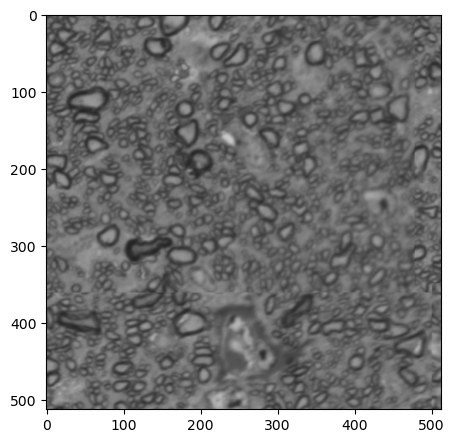

In [14]:
## define the tile coordinates (location of the tile on the shole image):
i = 8
j = 8
## import a specific tile:
tile = get_tile(tiles, i, j)
print(tile.shape)
print(tile.dtype)
print(np.min(tile))
print(np.max(tile))
## plot the tile as 2d-array:
plot_tile(tiles, i, j)
## save as a true grayscale image (only 1 channel); 
## N.B. plt.imsave(cmap=gray) does not save as true grayscale image but as RGBA
# img = Image.fromarray(tile.astype(np.uint8))
# img.save('test_tile.png')

#### Draw the histogram of grays:

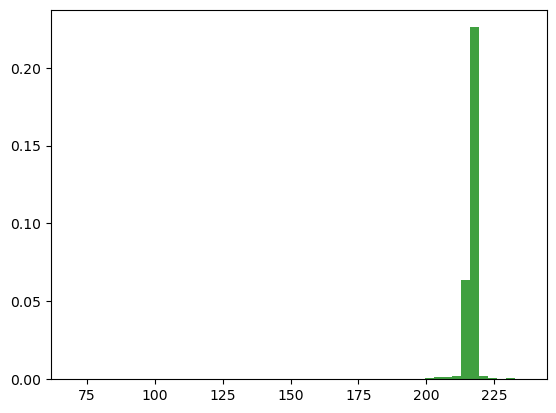

In [10]:
n, bins, patches = plt.hist(tile.flatten(), 50, density=True, facecolor='g', alpha=0.75)

## Random or manual selection of tiles that will be manually annotated

In [11]:
rng = np.random.default_rng(31418)
selection_size = 30
if species == "Hr11":
    ## Coordinates of the tiles selected for training/testing:
    ## For Hr11, the first analysed species, a pseudo-random manual selection was done (every 10th image is selected):
    tiles_in_selection = [
        (1,7), (3,3), (4,2), (4,11), (5,8),
        (6,5), (7,0), (7,9), (8,3), (8,12),
        (9,6), (9,15), (10,8), (11,1), (11,10),
        (12,2), (12,11), (13,3), (13,12), (14,4),
        (14,13), (15,6), (15,15), (16,8), (16,17), 
        (17,11), (18,6), (18,15), (19,12), (20,11),
        (21,11)
    ]
    ## copy to the folder selection the tiles selected for training/testing:
    if save_final_data:
        print("copying selected tiles from :", path2tiles)
        print("to :", path2selection)
        for t in tiles_in_selection:
            fname = 'tile_' + str(t[0]) + '_' + str(t[1]) + '.png'
            #print(fname)
            src = os.path.join(path2tiles, fname)
            dst = os.path.join(path2selection, fname)
            shutil.copyfile(src, dst)
else :    
    basepath = Path(path2tiles)
    files_in_basepath = (entry for entry in basepath.iterdir() if entry.is_file() and entry.name.endswith('.png'))
    fileList = [entry.name for entry in files_in_basepath]
    print(len(fileList))
    selection_list = []
    for i in range(selection_size):
        idx = rng.integers(low=0, high=len(fileList), endpoint=False)
        selection_list.append(fileList[idx])
    print(selection_list)
    if save_final_data:
        ## copy to folder selection the tiles selected for training/testing:
        print("copying selected tiles from :", path2tiles)
        print("to :", path2selection)
        for fname in selection_list:
            src = os.path.join(path2tiles, fname)
            dst = os.path.join(path2selection, fname)
            shutil.copyfile(src, dst)

## Plot the partition into tiles

Check which tiles were manually labeled:

In [12]:
(label_coords, tile_coords) = check_for_labels(path2selection) # passed as argument to partition_image
print("Coordinates of tiles in selection:", tile_coords)
print("Coordinates of tiles already labeled:", label_coords)

Coordinates of tiles in selection: [(14, 13), (12, 11), (15, 6), (8, 12), (13, 12), (4, 11), (9, 15), (5, 8), (8, 3), (15, 15), (18, 15), (11, 10), (17, 11), (16, 8), (20, 11), (14, 4), (19, 12), (16, 17), (10, 8), (12, 2), (9, 6), (1, 7), (18, 6), (7, 9), (21, 11), (4, 2), (3, 3), (11, 1), (7, 0), (6, 5), (13, 3)]
Coordinates of tiles already labeled: [(3, 3), (7, 0), (1, 7), (7, 9), (21, 11), (8, 12), (6, 5), (8, 3), (5, 8), (20, 11), (4, 11), (4, 2)]


image trimmed (right, up, left, bottom): (91, 228, 91, 227)
740


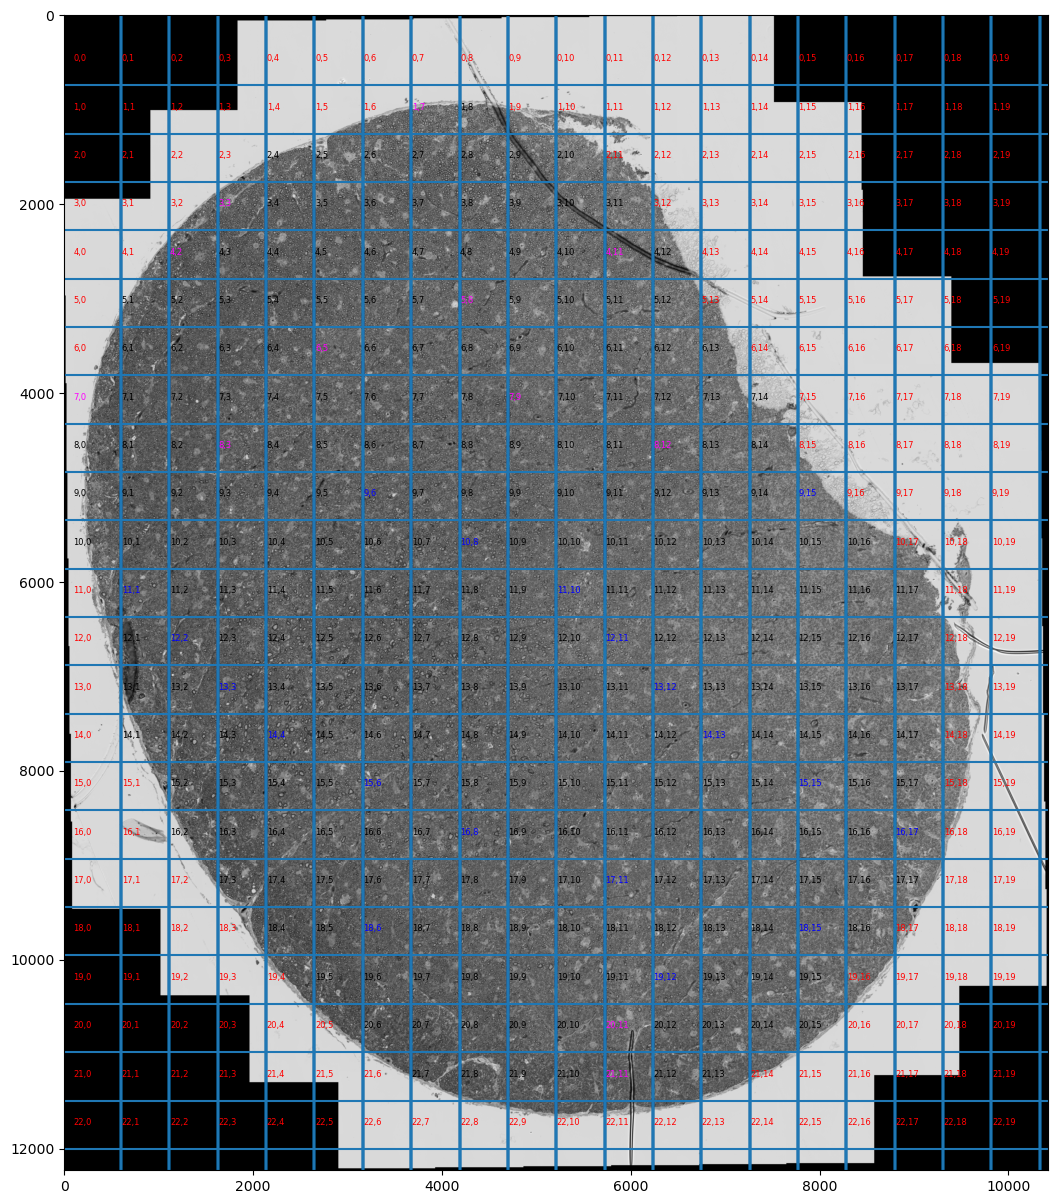

In [13]:
plot_tiling(im,
            tiles,
            label_coords=label_coords,
            tile_coords=tile_coords,
            savefig=save_final_data,
            path2save=os.path.join(path2data, 'partition_into_tiles_512x512.png'),
            labelsize=6
)

## Make some statistics on manually annotated tiles

In [31]:
def get_manually_annotated_polygons(path2directory):
    basepath = Path(path2directory)
    roisets = (entry for entry in basepath.iterdir() if entry.is_file() and entry.name.endswith('RoiSet.zip')) # generator
    roiset_names = [entry.name for entry in roisets]
    polygons_list = []
    for rs_name in roiset_names:
        path2roi = os.path.join(path2directory, rs_name)
        ## get the (i,j)-coordinates of the tile from filename:
        rs_name_splitted = re.split('_|\.', rs_name)
        i = rs_name_splitted[1]
        j = rs_name_splitted[2]
        #print(i,j)
        ## import rois from zip file:
        rois = read_roi_zip(path2roi)
        #print("tile (" + i + "," + j + ") - number of rois :", len(rois))
        ## convert rois to shapely.Polygon objects:
        for idx, r in enumerate(rois):
            poly = (r, contour2polygon(np.column_stack((rois[r]['x'], rois[r]['y']))))
            polygons_list.append(poly)
        ## sort in-place polygons from largest to smallest: 
        #polygons_list.sort(key=lambda x: x[1].area, reverse=True)

    return polygons_list
        

In [ ]:
areas_dict = {}
areas_largest_dict = {}
areas_smallest_dict = {}
cut_quantiles = {}
nb_largest = 5
cut_quantile_prob = 0.95
for s in ['Hr11', 'Aa06', 'Cl']:
    px_r = PX_RATIOS[s]
    #print(f"micron/pixel ratio for {s}: {px_r}")
    polygons = get_manually_annotated_polygons(
        os.path.join(path2kdrive, "cellcount/data/preprocessing", s, "ON1_1/selection")
    )
    areas = [polygons[i][1].area * px_ratio ** 2 for i in range(len(polygons))]
    areas.sort(reverse=True)
    areas = np.array(areas)
    #areas = np.sort(areas)
    q = np.quantile(areas, cut_quantile_prob)
    #print("quantile", q)
    areas_head = areas[areas > q]   
    areas_dict[s] = areas_head
    areas_largest_dict[s] = areas[:nb_largest]
    areas_smallest_dict[s] = areas[-1]
    cut_quantiles[s] = q


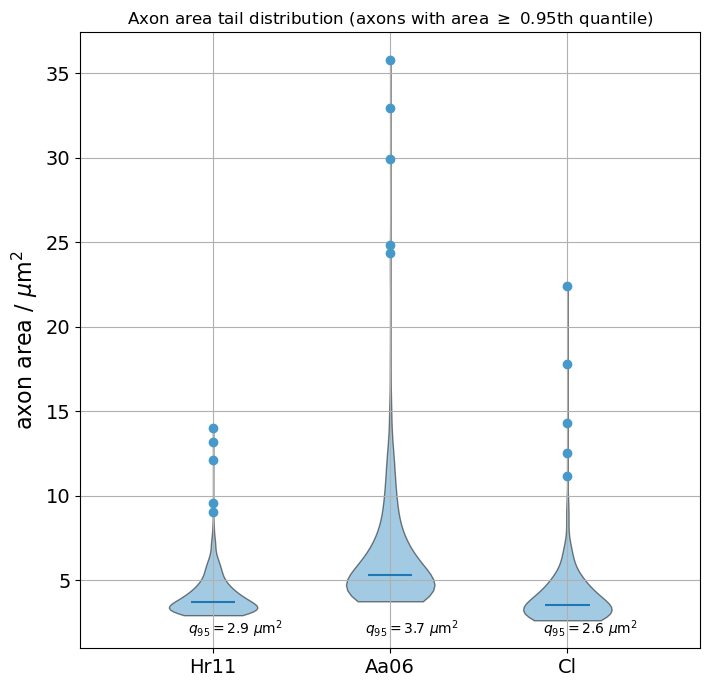

In [ ]:
## set fontsize of the tick labels
plt.rc('xtick', labelsize=14)    
plt.rc('ytick', labelsize=14)

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(1, 1, 1)
ax.set_xticks(np.arange(1,4))
ax.set_xticklabels(list(areas_dict.keys()))
ax.set_xlim(0.25, 3 + 0.75)
ax.grid(zorder=0)

violin = ax.violinplot([areas_dict['Hr11'], areas_dict['Aa06'], areas_dict['Cl']], showmeans=False, showmedians=True, showextrema=False)
ax.scatter(x=np.ones((1, nb_largest)), y= areas_largest_dict['Hr11'], color='#4699C9', zorder=3)
ax.scatter(x=2*np.ones((1, nb_largest)), y= areas_largest_dict['Aa06'], color='#4699C9', zorder=3)
ax.scatter(x=3*np.ones((1, nb_largest)), y= areas_largest_dict['Cl'], color='#4699C9', zorder=3)
ax.text(0.86, 1.8, '$q_{95}=$' + str(round(cut_quantiles['Hr11'], 1)) + ' $\mu$m$^2$')
ax.text(1.86, 1.8, '$q_{95}=$' + str(round(cut_quantiles['Aa06'], 1)) + ' $\mu$m$^2$')
ax.text(2.86, 1.8, '$q_{95}=$' + str(round(cut_quantiles['Cl'], 1)) + ' $\mu$m$^2$')
for pc in violin["bodies"]:
    pc.set_facecolor('#4699C9')
    pc.set_edgecolor('black')
    pc.set_alpha(0.5)

#ax.set_xlabel('species', fontsize=16)
ax.set_ylabel('axon area / $\mu$m$^2$', fontsize=16)
ax.set_title(f'Axon area tail distribution (axons with area $\geq$ {cut_quantile_prob}th quantile)')

if save_intermediary_data:
    fig.savefig(os.path.join(path2kdrive, "cellcount/data/onunet/optical_nerve/manually_counted_largest_axons.png"), facecolor='white')
    

## Preparing the train and validation sets

Species should be one for which some tiles were manually annotated (Hr11, Aa06 or Cl)

In [ ]:
print(path2selection)

/home/jovyan/kDrive/cellcount/data/preprocessing/Aa06/ON1_1/selection


### Generate labels (binary masks) from rois (regions of interest) manually annotated

In [ ]:
def prepare_labels(path2directory, validation=False, savedata=False):
    basepath = Path(path2directory)
    roisets = (entry for entry in basepath.iterdir() if entry.is_file() and entry.name.endswith('RoiSet.zip')) # generator
    roiset_names = [entry.name for entry in roisets]
    labels = []
    for rs_name in roiset_names:
        path2roi = os.path.join(path2directory, rs_name)
        ## get the (i,j)-coordinates of the tile from filename:
        rs_name_splitted = re.split('_|\.', rs_name)
        i = rs_name_splitted[1]
        j = rs_name_splitted[2]
        print(i,j)
        path2mask = os.path.join(path2directory, "label_" + str(i) + "_" + str(j) + ".png")
        path2log = os.path.join(path2directory, "label_" + str(i) + "_" + str(j) + ".log")
        ## import rois from zip file:
        rois = read_roi_zip(path2roi)
        print("tile (" + i + "," + j + ") - number of rois :", len(rois))
        ## convert rois to shapely.Polygon objects:
        polygons_list = []
        for idx, r in enumerate(rois):
            poly = (r, contour2polygon(np.column_stack((rois[r]['x'], rois[r]['y']))))
            polygons_list.append(poly)
        ## sort in-place polygons from  smallest to largest: 
        polygons_list.sort(key=lambda x: x[1].area, reverse=False)

        ## Generate and save a mask from the collection of rois:
        print('Generate a binary mask from the collection of rois...')
        log_file = open(path2log, 'w')
        mask = np.empty((512, 512, len(rois)))
        polygons_no_overlaps = []
        for idx, poly in enumerate(polygons_list):
            if idx < 3000 :
                roi_id = poly[0]
                ## check if geometry is a valid polygon ; if not, make it valid and retain as polygon the largest connected component :
                if not poly[1].is_valid:
                    unvalid_msg = " - Unvalid polygon -> making it valid by keeping the connected component with greatest area\n"
                    log_file.write(roi_id + ' : ' + explain_validity(poly[1]) + unvalid_msg)
                    p = make_valid(poly[1]) # output can be either a MultiPolygon or a Collection of geometries
                    #print(type(p))
                    if isinstance(p, Polygon):
                        poly_valid = (roi_id, p)
                    else:
                        main_comp = get_main_component(p)
                        while not isinstance(main_comp, Polygon):
                            main_comp = get_main_component(main_comp)
                        
                        poly_valid = (roi_id, main_comp)                          
                else:
                    poly_valid = poly

                ## Remove intersections and separate touching polygons:
                p_trim = poly_valid[1]
                if len(polygons_no_overlaps) > 0:
                    for p in polygons_no_overlaps:
                        if p_trim.intersects(p[1]):
                            log_file.write(roi_id + " : Removing intersection with " + p[0] + "\n")
                            #print(i, ': removing intersection')
                            p_trim = p_trim.difference(p[1])
                    
                    for p in polygons_no_overlaps:
                        d = p_trim.distance(p[1])
                        if d < 1.01:
                            tr_band = 1.01 - d
                            p_trim = p_trim.buffer(-tr_band)
                            log_file.write(roi_id + " : Trimming polygon touching " + p[0] + " by " + str(tr_band) + "\n")
                            if not isinstance(p_trim, Polygon):
                                p_trim = get_main_component(p_trim)

                #log_file.write(str(type(p_trim)) + "\n")
                poly_trimmed = (roi_id, p_trim) 
                polygons_no_overlaps.append(poly_trimmed)
                xy = polygon2contour(poly_trimmed[1])
                
                ## check which gridpoints are in polygon xy:
                maskint = measure.grid_points_in_poly(shape=(512, 512), verts=xy) # this takes time
                mask[:,:,idx] =  maskint

            else:
                break

        log_file.close()

        ## compute main (binary) mask : a gridpoint is black if no polygon contains it 
        mainmask = np.empty(mask.shape[:2])
        for k in range(mask.shape[0]):
            for l in range(mask.shape[1]):
                mainmask[l,k] = min([np.sum(mask[k,l,:]), 1])

        img = Image.fromarray(255 * mainmask.astype(np.uint8))
        #img.show()
        if savedata:
            img.save(path2mask)
        labels.append(mainmask)
        ## if true, check if the above produced binary mask allows to get back the contours properly (save figures in path2directory)
        if validation: 
            path2tile = os.path.join(path2directory, "tile_" + str(i) + "_" + str(j) + ".png")
            path2contours = os.path.join(path2directory, "contours_from_mask_" + str(i) + "_" + str(j) + ".png")
            path2cellmarks = os.path.join(path2directory, "cellmarks_" + str(i) + "_" + str(j) + ".png")
            im_tile = Image.open(path2tile)
            im_tile_data = np.asarray(im_tile)
            #im_label = Image.open(path2mask)
            im_label = img
            im_label_data = np.asarray(im_label)
            im_label_scaled = im_label_data[:,:]/255
            im_tile_scaled = im_tile_data[:,:]/255
            cellmarks = cell_contours(im_tile_scaled, im_label_scaled, 0.5, True, path2contours, figsize=(30, 20))
            # Plot image with cellmarks:
            fig = plt.figure(figsize=(20, 20))
            plt.imshow(im_tile_scaled, cmap=plt.cm.gray)
            for cm in cellmarks:
                plt.plot(cm[:, 1], cm[:, 0], linewidth=1)
            plt.title('original image with contours derived from segmentation: ' + str(len(cellmarks)) + ' elements' + ' (against ' + str(len(rois)) + ' manually annotated)')
            plt.close(fig)
            fig.savefig(path2cellmarks, facecolor='white')

    return labels

In [ ]:
## it takes time !
labels = prepare_labels(path2directory=path2selection, validation=False, savedata=False)

19 6
tile (19,6) - number of rois : 922
Generate a binary mask from the collection of rois...
7 7
tile (7,7) - number of rois : 910
Generate a binary mask from the collection of rois...
18 3
tile (18,3) - number of rois : 958
Generate a binary mask from the collection of rois...
25 12
tile (25,12) - number of rois : 732
Generate a binary mask from the collection of rois...
3 10
tile (3,10) - number of rois : 742
Generate a binary mask from the collection of rois...


/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3

14 11
tile (14,11) - number of rois : 566
Generate a binary mask from the collection of rois...


/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/conda/lib/python3

22 6
tile (22,6) - number of rois : 925
Generate a binary mask from the collection of rois...
10 5
tile (10,5) - number of rois : 1088
Generate a binary mask from the collection of rois...
22 9
tile (22,9) - number of rois : 1007
Generate a binary mask from the collection of rois...
14 10
tile (14,10) - number of rois : 578
Generate a binary mask from the collection of rois...
16 2
tile (16,2) - number of rois : 1052
Generate a binary mask from the collection of rois...
23 15
tile (23,15) - number of rois : 228
Generate a binary mask from the collection of rois...
17 3
tile (17,3) - number of rois : 902
Generate a binary mask from the collection of rois...
19 12
tile (19,12) - number of rois : 800
Generate a binary mask from the collection of rois...
23 5
tile (23,5) - number of rois : 1029
Generate a binary mask from the collection of rois...
13 11
tile (13,11) - number of rois : 875
Generate a binary mask from the collection of rois...


### Define a weight map for each labeled image

In [42]:
def unet_weight_map(y, wc=None, w0=10, sigma=2, dummy=False):

    """
    Generate weight maps as specified in the U-Net paper
    for boolean mask.

    "U-Net: Convolutional Networks for Biomedical Image Segmentation"
    https://arxiv.org/pdf/1505.04597.pdf

    Parameters
    ----------
    y: Numpy array
        2D array of shape (image_height, image_width) representing binary mask
        of objects.
    wc: dict
        Dictionary of weight classes.
    w0: int
        Border weight parameter.
    sigma: int
        Border width parameter.

    Returns
    -------
    Numpy array
        Training weights. A 2D array of shape (image_height, image_width).
    """

    if dummy:
        return np.ones_like(y)

    labels = measure.label(y)
    no_labels = labels == 0 # background
    label_ids = sorted(np.unique(labels))[1:]

    if len(label_ids) > 1:
        distances = np.zeros((y.shape[0], y.shape[1], len(label_ids)))

        for i, label_id in enumerate(label_ids):
            distances[:,:,i] = distance_transform_edt(labels != label_id)

        distances = np.sort(distances, axis=2)
        d1 = distances[:,:,0]
        d2 = distances[:,:,1]
        w = w0 * np.exp(-(d1 + d2)**2 / (2 * sigma**2)) * no_labels
    else:
        w = np.zeros_like(y)

    class_weights = np.ones_like(y)
    if wc is not None:    
        for k, v in wc.items():
            class_weights[y == k] = v
    
    w = w + class_weights
    return w

In [43]:
def prepare_weights_maps(path2directory, w0, sigma, class_weighting=False, dummy=False):
    basepath = Path(path2directory)
    label_images = (entry for entry in basepath.iterdir() if entry.is_file() and entry.name.startswith('label_') and entry.name.endswith('.png')) # generator
    label_names = [entry.name for entry in label_images]
    weights_list = []
    max_weight = 0
    for ln in label_names:
        ## get the (i,j)-coordinates of the tile from filename:
        ln_splitted = re.split('_|\.', ln)
        i = ln_splitted[1]
        j = ln_splitted[2]
        print(i,j)
        binary_mask = import_label_asarray(path2directory, i, j, species=None, show_label=False) / 255
        wc = None
        if class_weighting: ## this is not used as class are reasonnably well balanced
            ## compute class balance weights:
            foreground_size = np.sum(binary_mask) # the number of ones, representing axons
            background_size = np.size(binary_mask) - foreground_size # the number of zeros, representing background
            fore2back_ratio = foreground_size/background_size
            print(f"foreground to background ratio for tile ({i},{j}): {fore2back_ratio}")
            wc = {
                0: fore2back_ratio, # background
                1: 1 # objects
            }
        
        weights = unet_weight_map(binary_mask, wc, w0, sigma, dummy)
        
        print(f"Minimum weight for current label: {weights.min()}")
        print(f"Maximum weight for current label: {weights.max()}")
        max_weight = max(max_weight, weights.max())

        weights_list.append((weights, i, j))

    return weights_list, max_weight


def save_normalized_weight_maps(weights_list, path2directory, normalizing_factor=None):
    for weights in weights_list:
        W, i, j = weights        
        path2weights_img = os.path.join(path2directory, "weights_" + str(i) + "_" + str(j) + ".png")
        ## save as an image:
        if normalizing_factor is not None:
            W_rescaled = (W / normalizing_factor * 255).astype(np.uint8)
        else:
            W_rescaled = (W / W.max() * 255).astype(np.uint8)

        img_weights = Image.fromarray(W_rescaled)
        img_weights.save(path2weights_img)

    return None

#### Test the weight map:

(512, 512)
uint8


1.0

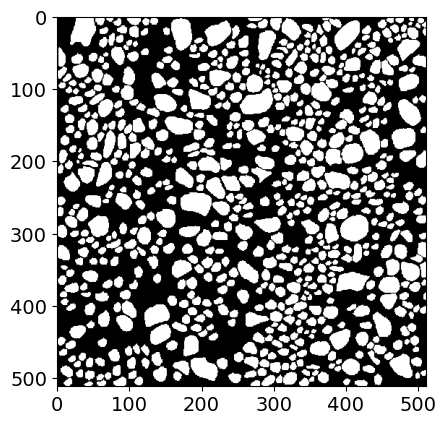

In [44]:
mask = import_label_asarray(os.path.join(path2train, 'labels'), i=25, j=12, species='Aa06', show_label=True) / 255
#n, bins, patches = plt.hist(mask.flatten(), 50, density=True, facecolor='g', alpha=0.75)
np.max(mask)

In [45]:
## compute class balance weights:
foreground_size = np.sum(mask)
background_size = np.size(mask) - foreground_size
fore2back_ratio = foreground_size/background_size
fore2back_ratio

0.7586475244867839

Since the background/foreground classes are reasonnably well-balanced, we currently do not add any class balancing in the weights.   

In [46]:
# wc = {
#     0: fore2back_ratio, # background
#     1: 1 # objects
# }
w = unet_weight_map(mask, w0=3, sigma=4)

Weight matrix dimensions: (512, 512)
Extreme weight values: min=1.0 ; max=3.6474907077537866


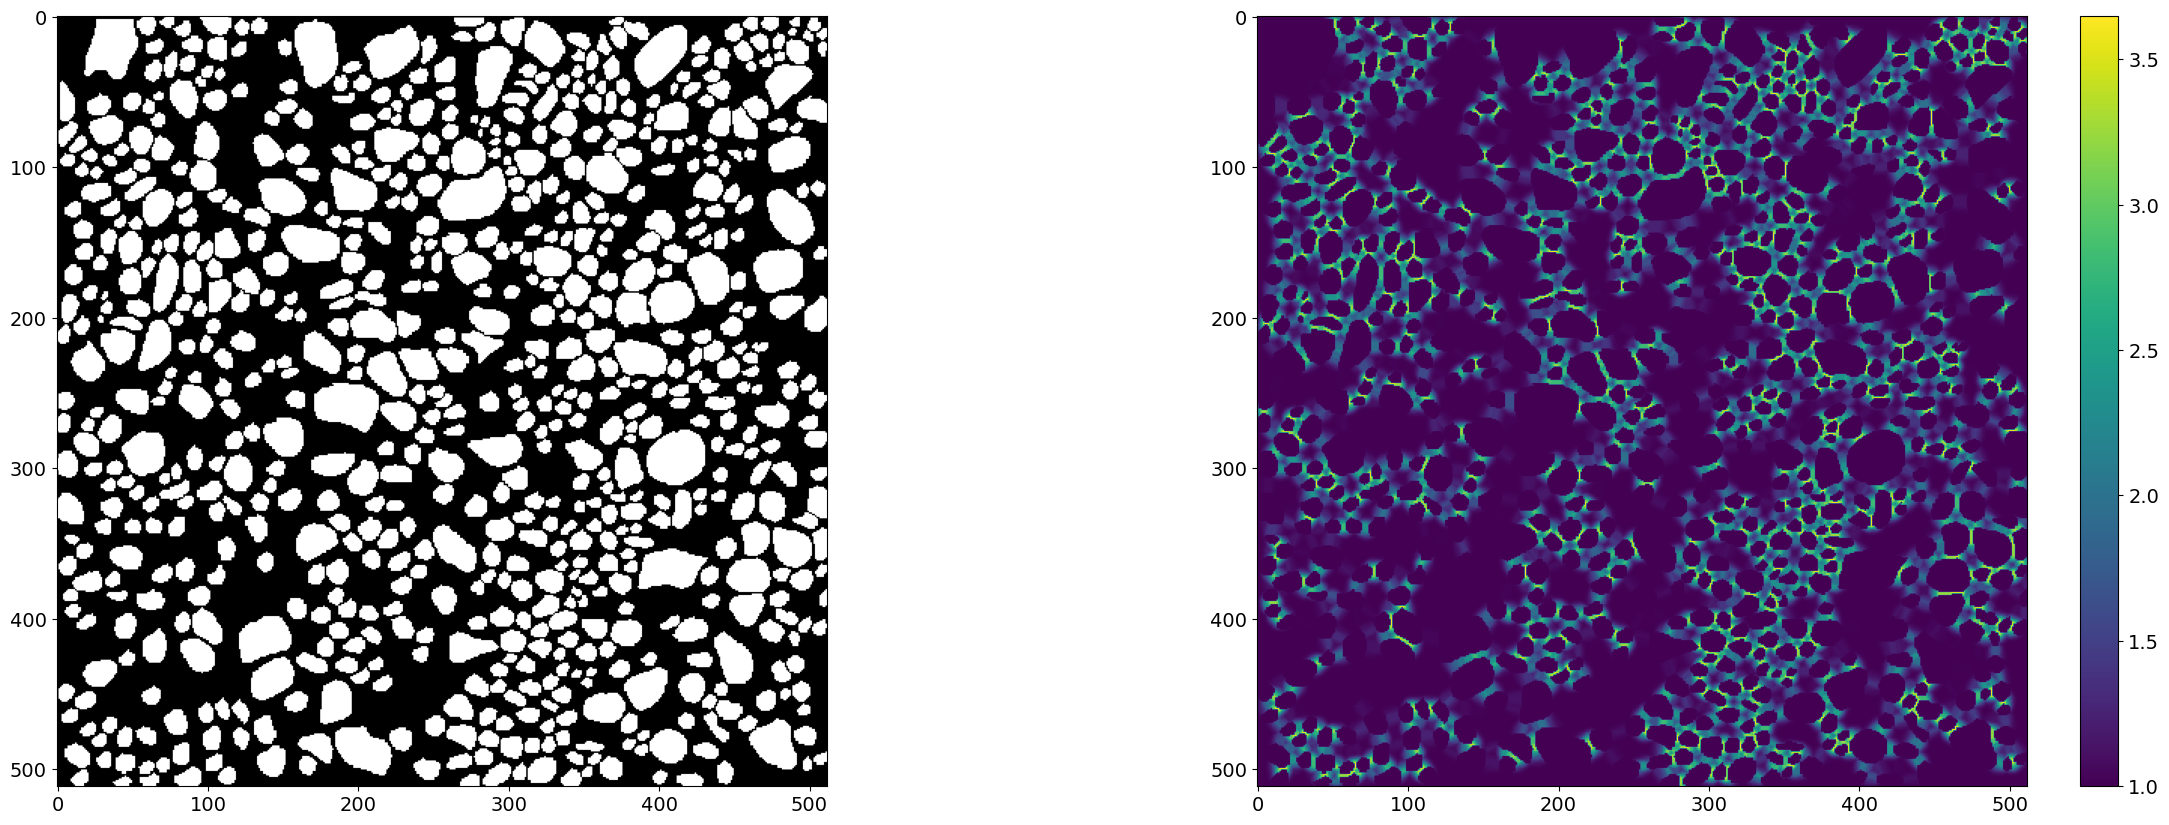

In [57]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(30,10))
img_mask = ax1.imshow(mask, cmap='gray', vmin=0, vmax=1)
img_weights = ax2.imshow(w)
plt.colorbar(img_weights)
print(f"Weight matrix dimensions: {w.shape}")
print(f"Extreme weight values: min={np.min(w)} ; max={np.max(w)}")

Plot the repartition of weights:

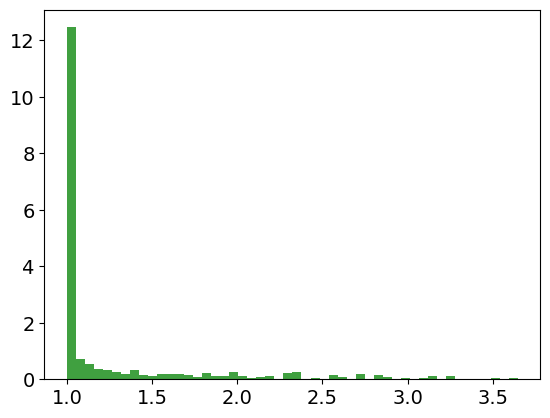

In [48]:
n, bins, patches = plt.hist(w.flatten(), 50, density=True, facecolor='g', alpha=0.75)

Test the import of a weight matrix:

In [ ]:
path2testdirectory = os.path.join(path2kdrive, 'cellcount', 'data', 'onunet', 'optical_nerve', 'train', 'weights')
print(path2testdirectory)
weights = import_weight_asarray(path2testdirectory, i=25, j=12, species='Aa06')

/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/train/weights
(512, 512)
uint8


Weight matrix dimensions: (512, 512)
Extreme weight values: min=69 ; max=255


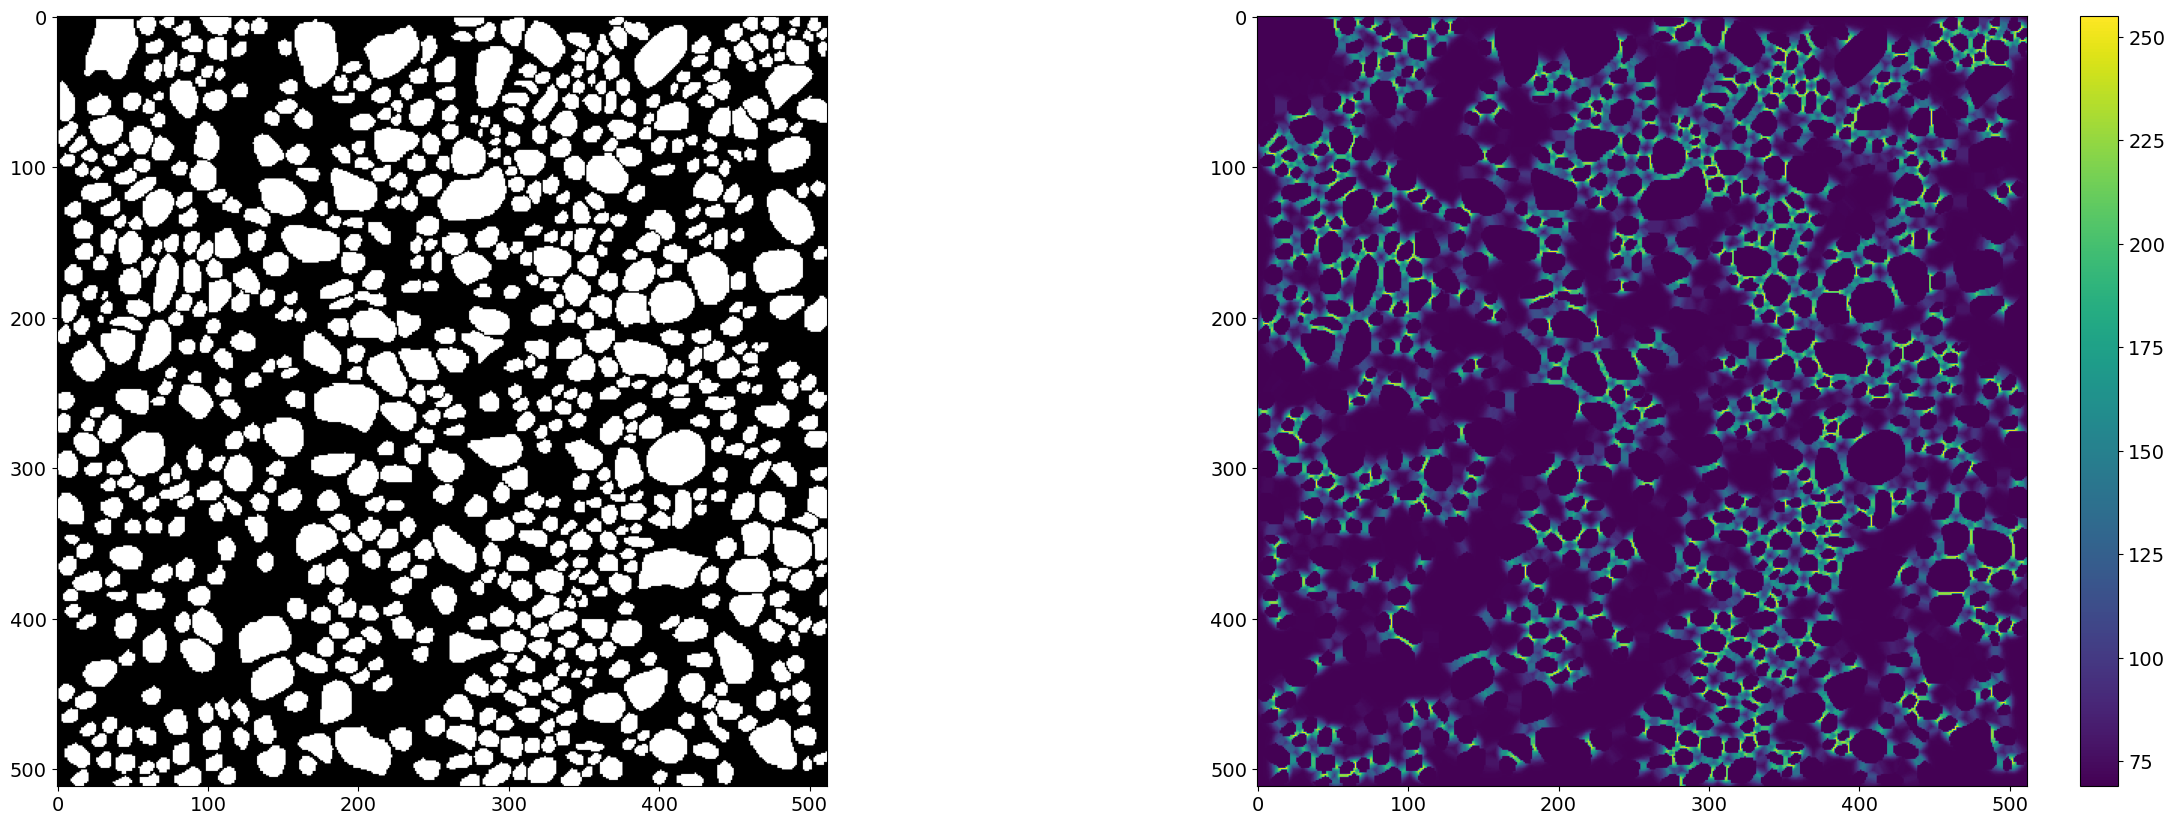

In [62]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(30,10))
img_mask = ax1.imshow(mask, cmap='gray', vmin=0, vmax=1)
img_weights = ax2.imshow(weights)
plt.colorbar(img_weights)
print(f"Weight matrix dimensions: {weights.shape}")
print(f"Extreme weight values: min={np.min(weights)} ; max={np.max(weights)}")

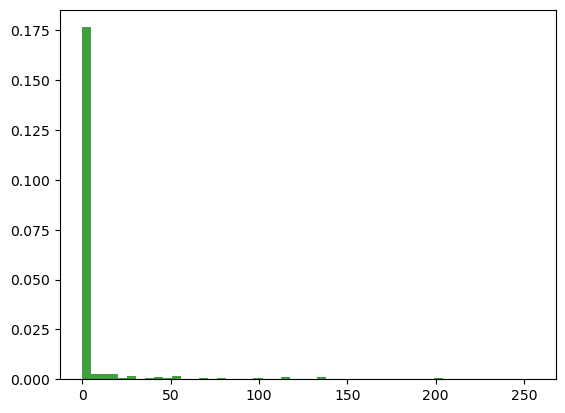

In [11]:
n, bins, patches = plt.hist(weights.flatten(), 50, density=True, facecolor='g', alpha=0.75)

**N.B.** Since saving correctly a weight map as an image implies rescaling the values between 0 and 255, we will have to rescale back when importing the weightrs for training.

#### Generate and save weight maps for each labeled image for given species:

In [ ]:
SPECIES_LIST = ['Aa06'] #['Aa06', 'Hr11', 'Cl']
weight_maps_list = {}
maximum_weight_accross_all_species = 0
for sp in SPECIES_LIST:
    path2labels = os.path.join(path2kdrive, "cellcount/data/preprocessing", sp, "ON1_1/selection")
    print(path2labels)
    weight_maps_list[sp], max_weight = prepare_weights_maps(path2labels, w0=3, sigma=4, class_weighting=False, dummy=False)
    maximum_weight_accross_all_species = max(max_weight, maximum_weight_accross_all_species)

print(f"Maximum attributed pixel weight accross all species used for training: {maximum_weight_accross_all_species}")
if save_final_data:
    # save all map weights as an image (normalized by common factor)
    for sp in SPECIES_LIST:
        path2labels = os.path.join(path2kdrive, "cellcount/data/preprocessing", sp, "ON1_1/selection")
        save_normalized_weight_maps(weight_maps_list[sp], path2labels, normalizing_factor=maximum_weight_accross_all_species)


/home/jovyan/kDrive/cellcount/data/preprocessing/Aa06/ON1_1/selection
25 12
(512, 512)
uint8
Minimum weight for current label: 1.0
Maximum weight for current label: 3.6474907077537866
17 3
(512, 512)
uint8
Minimum weight for current label: 1.0
Maximum weight for current label: 3.6474907077537866
10 5
(512, 512)
uint8
Minimum weight for current label: 1.0
Maximum weight for current label: 3.6474907077537866
14 11
(512, 512)
uint8
Minimum weight for current label: 1.0
Maximum weight for current label: 3.6474907077537866
14 10
(512, 512)
uint8
Minimum weight for current label: 1.0
Maximum weight for current label: 3.6474907077537866
23 15
(512, 512)
uint8
Minimum weight for current label: 1.0
Maximum weight for current label: 3.6474907077537866
19 6
(512, 512)
uint8
Minimum weight for current label: 1.0
Maximum weight for current label: 3.6474907077537866
3 10
(512, 512)
uint8
Minimum weight for current label: 1.0
Maximum weight for current label: 3.6474907077537866
19 12
(512, 512)
uint8

### Split the labeled images gathered in folder "selection" (and the corresponding tiles) into train/validation sets

In [ ]:
random.seed(314)
# print(path2train)
# print(path2validation)
for sp in ['Aa06', 'Hr11', 'Cl']:
    path2labels = os.path.join(path2kdrive, "cellcount/data/preprocessing", sp, "ON1_1/selection")
    split_train_test(path2labels, path2train, path2validation, sp, 0.85)

/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/train
/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/validation


## For testing, import a given tile and the corresponding label and weights

In [68]:
MAXIMUM_WEIGHT_ACCROSS_ALL_SPECIES = 3.64749
# i, j = 3, 3
# sp = 'Hr11'
i, j, = 25, 12
sp = 'Aa06'
path2tile = path2train
my_tile = import_tile_asarray(path2data=os.path.join(path2tile, "images"), i=i, j=j, species=sp, show_tile=False)
my_label = import_label_asarray(path2data=os.path.join(path2tile, "labels"), i=i, j=j, species=sp, show_label=False)
my_weights = import_weight_asarray(path2data=os.path.join(path2tile, "weights"), i=i, j=j, species=sp, show_weights=False) # between 0 and 255
my_weights_rescaled = my_weights /  255 * MAXIMUM_WEIGHT_ACCROSS_ALL_SPECIES
print(f"Minimum weight: {np.min(my_weights_rescaled)}; maximum weight: {np.max(my_weights_rescaled)}")

(512, 512)
uint8
(512, 512)
uint8
(512, 512)
uint8
Minimum weight: 0.9869678823529411; maximum weight: 3.64749


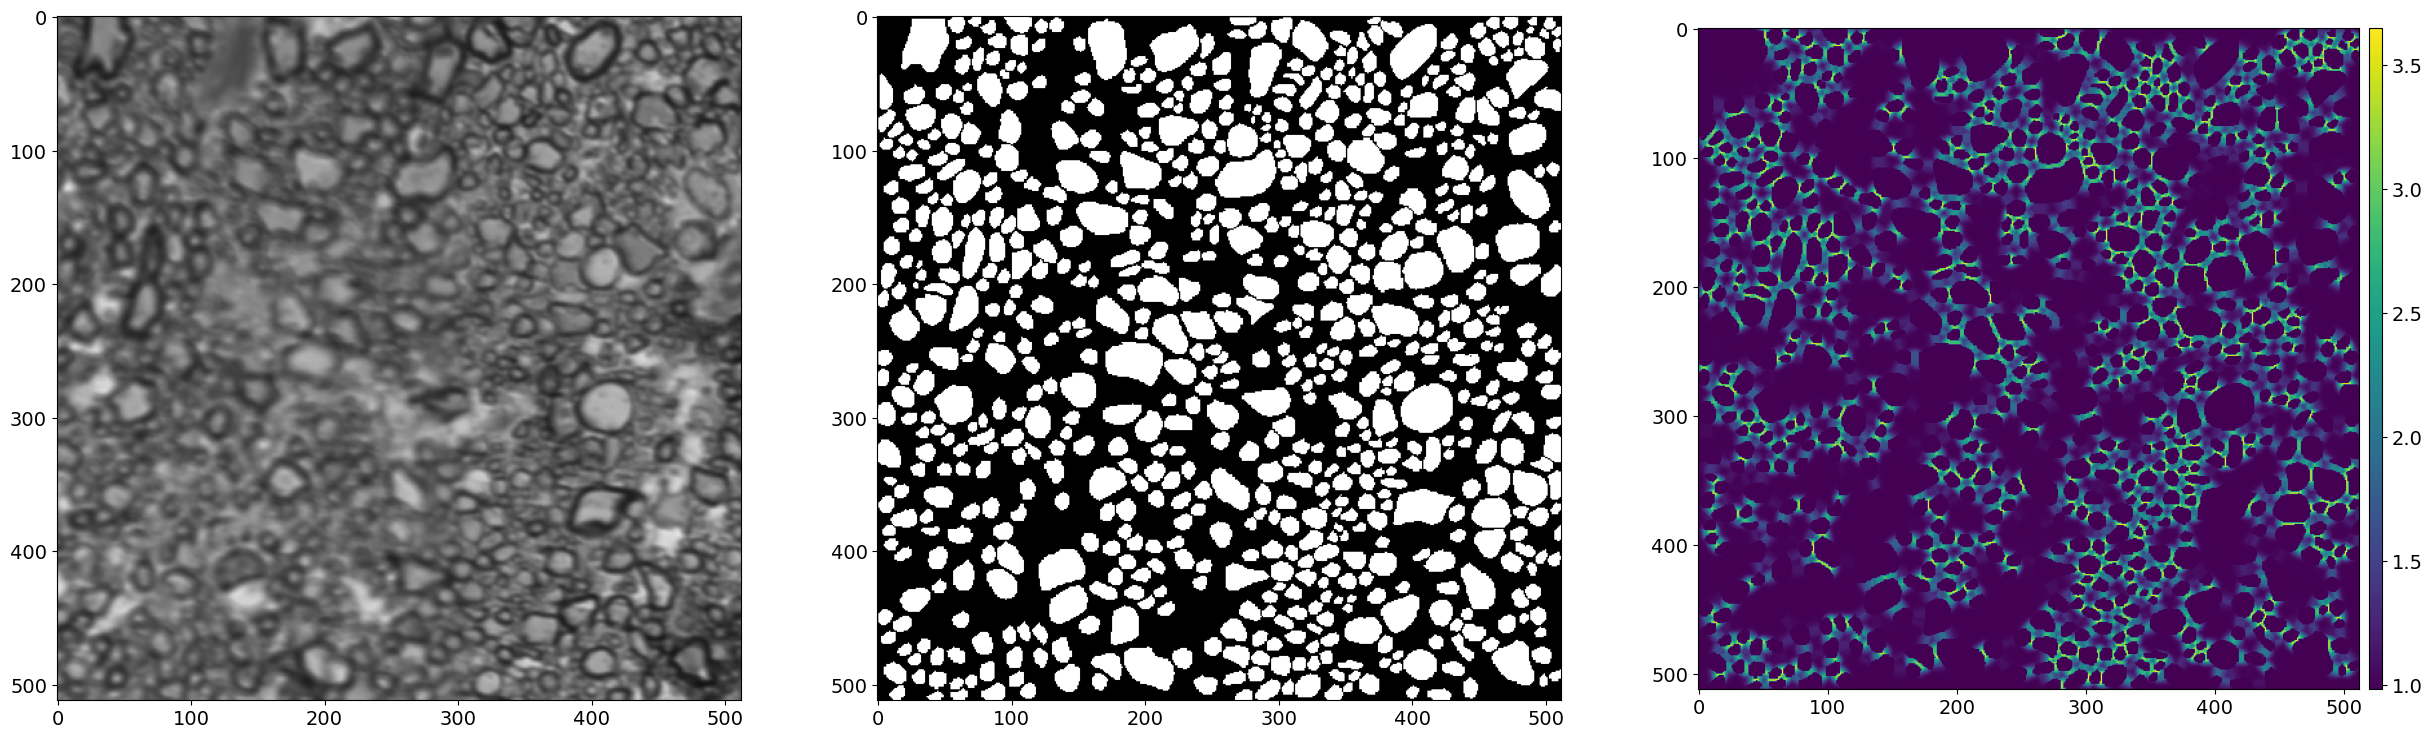

In [69]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(30,10))
img = ax1.imshow(my_tile, cmap='gray', vmin=0, vmax=255)
img_mask = ax2.imshow(my_label, cmap='gray', vmin=0, vmax=255)
img_weights = ax3.imshow(my_weights_rescaled)
# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(ax3)
cax3 = divider.append_axes("right", size="2%", pad=0.1) 
plt.colorbar(img_weights, cax=cax3)

0.9869678823529411 3.64749


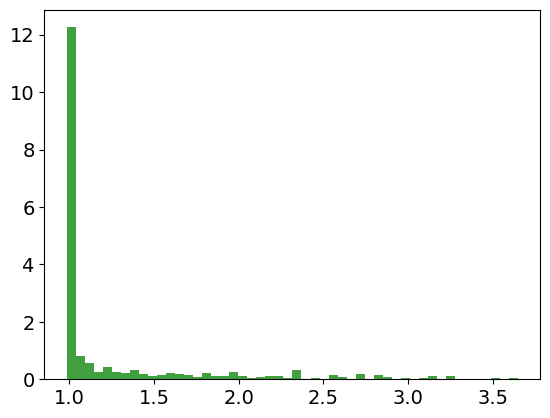

In [70]:
n, bins, patches = plt.hist(my_weights_rescaled.flatten(), 50, density=True, facecolor='g', alpha=0.75)
print(my_weights_rescaled.min(), my_weights_rescaled.max())

## Getting contours from CNN segmented image:

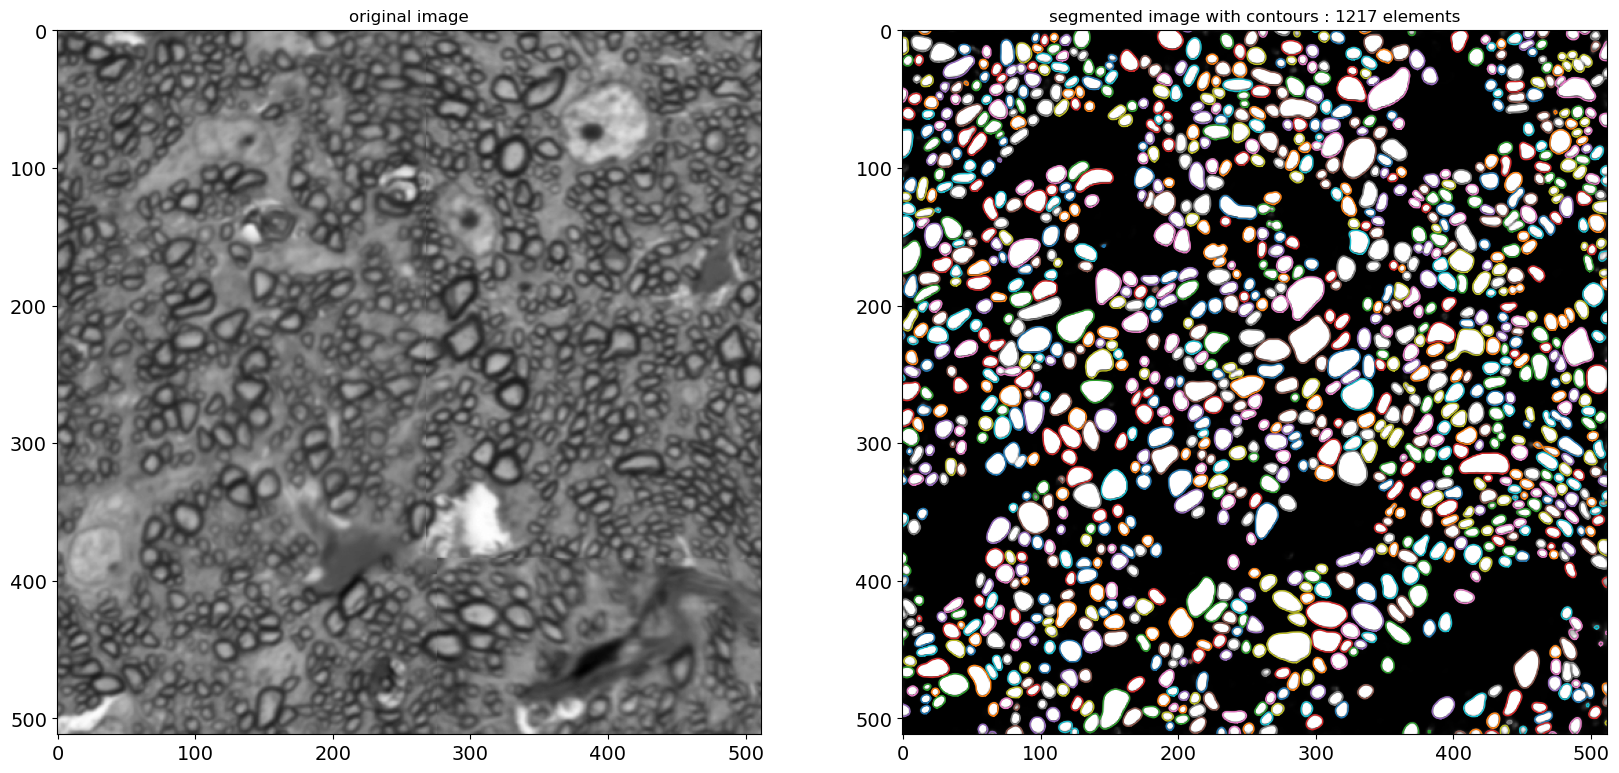

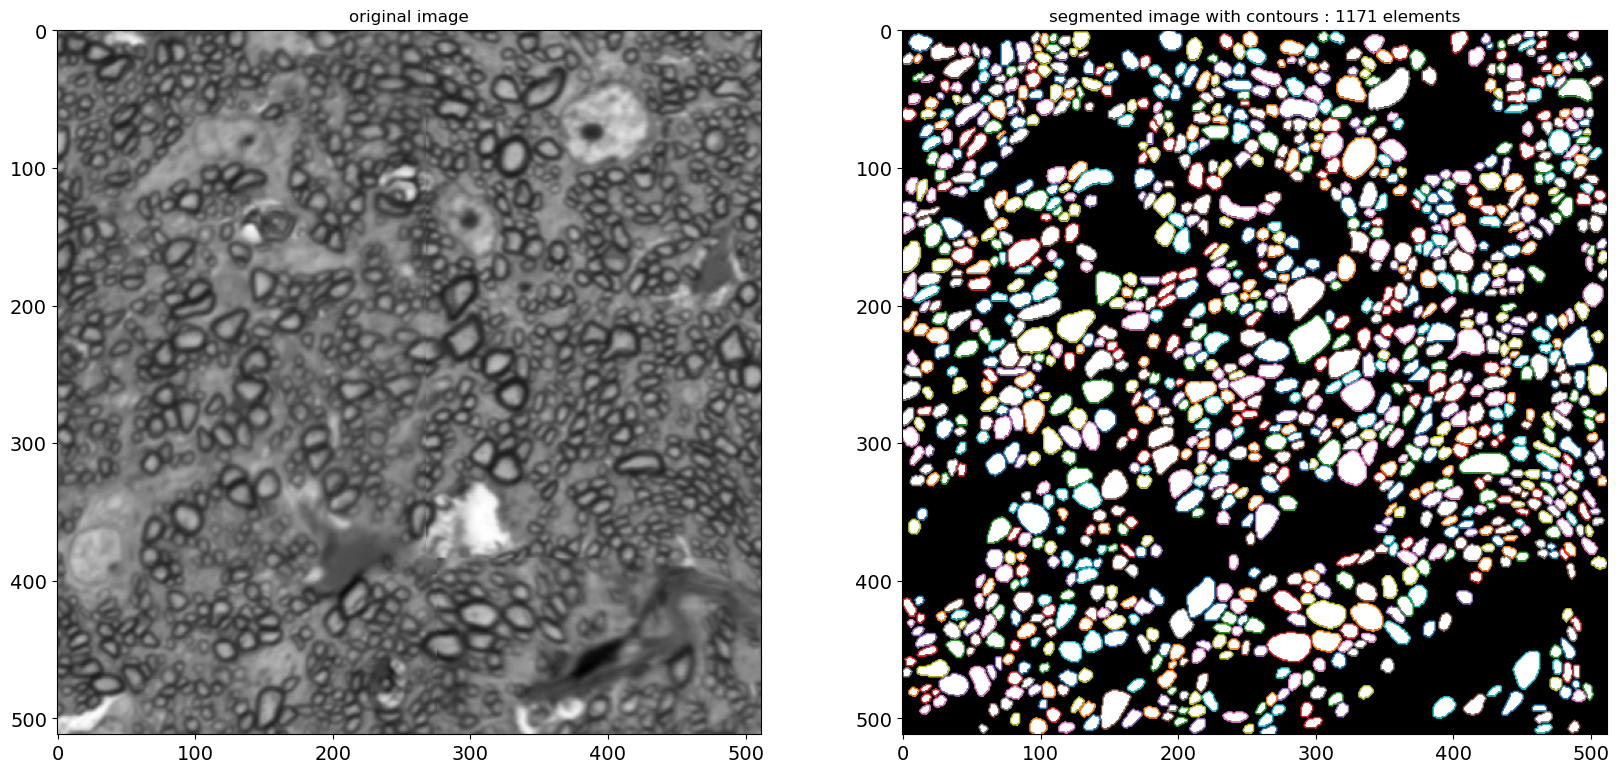

In [ ]:
path2image1 = os.path.join(path2test, "tile_Hr11_8_3.png")
path2image2 = os.path.join(path2test, "predict_8_3.png")
path2image3 = os.path.join(path2test, "label_Hr11_8_3.png")
img1 = io.imread(path2image1)
#print(np.array(img1).shape)
img2 = io.imread(path2image2)
img3 = io.imread(path2image3)
# print(np.max(img1))
# print(np.max(img2))
img1_scaled = img1/255
img2_scaled = img2/255
img3_scaled = img3/255
# print(img1.dtype)
# print(img2.dtype)
# print(np.max(img1_scaled))
# print(np.max(img2_scaled))
#io.imshow(im)

## contours from prediction:
contours_list = cell_contours(img1_scaled, img2_scaled, thr=0.25, savefig=False, figsize=(20, 20), fully_connected='low', positive_orientation='low')
#n, bins, patches = plt.hist(np.array(img2_scaled).flatten(), 50, density=True, facecolor='g', alpha=0.75)

## contours from manually labeled image:
contours_list_check = cell_contours(img1_scaled, img3_scaled, thr=0.25, savefig=False, figsize=(20, 20), fully_connected='low', positive_orientation='low')